In [1]:
%load_ext autoreload
import sys
from pathlib import Path
import networkx as nx
import numpy as np
import cvxpy as cp
import seaborn as sns
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import scipy.linalg as sla

In [2]:
project_root = Path().resolve()
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2    
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.utils import rng, seed
from lib.config import BASE_CONF, LOGFILE, GLOBAL_SEED, NUM_NODES

## Graph Examples

In [4]:
# Parameters
num_nodes = NUM_NODES
b = BASE_CONF['sys']['b']
local_rng = rng('graphs-global')

In [5]:
target_pi = local_rng.dirichlet(np.full(num_nodes,1))

In [6]:
%%capture
fig, ax = plt.subplots(1,1, figsize=(6,4))
sns.barplot(x=np.arange(num_nodes), y=np.sort(target_pi)[::-1], ax=ax)
ax.axhline(1/num_nodes, ls="--", color="crimson")
ax.set_title("Stationary Weight Distribution")
plt.show()

In [7]:
%%capture
gf = GraphFactory(num_nodes, b, seed('graphs-graph-factory'))
fig, ax = plt.subplots(2,2,figsize=(10,8))

In [8]:
%%capture
graph_args = {
    'ws_k': 4,
    'ws_p': 0.1,
    'MH_target_pi':target_pi
}
gf1 = GraphFactory(num_nodes, 3, seed('graphs-graph-factory-1'))
G,W,sampling_subset = gf1.create_graph("watts-strogatz", "MH_gen", **graph_args)
B = local_rng.choice(sampling_subset, size=3, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[0][0])
ax[0][0].set_title("Watts-Strogatz")

In [9]:
%%capture
graph_args = {
    'MH_target_pi':target_pi,
    'rand_reg_deg':b+1,
}
gf2 = GraphFactory(num_nodes, b, seed('graphs-graph-factory-1'))
G, W, sampling_subset = gf2.create_graph("random-regular", "MH_gen", **graph_args)
B = local_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[0][1])
ax[0][1].set_title("Complete")

In [10]:
%%capture
graph_args = {
    'er_p': min(1.0, 3.0 * np.log(num_nodes) / num_nodes),
    # 'MH_target_pi':target_pi
}
gf3 = GraphFactory(num_nodes, b, seed('graphs-graph-factory-1'))
G, W, sampling_subset = gf3.create_graph("erdos-renyi", "MH", **graph_args)
B = local_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[1][0])
ax[1][0].set_title("Erdos-Renyi")

In [11]:
%%capture
graph_args = {
    'geom_radius': 0.4,
    'MH_target_pi':target_pi
}
gf4 = GraphFactory(num_nodes, b, seed('graphs-graph-factory-1'))
G, W, sampling_subset = gf4.create_graph("geometric", "MH", **graph_args)
B = local_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
assert nx.is_connected(G.subgraph(H))

add_graph_plot(G,B,ax[1][1])
ax[1][1].set_title("Geometric")

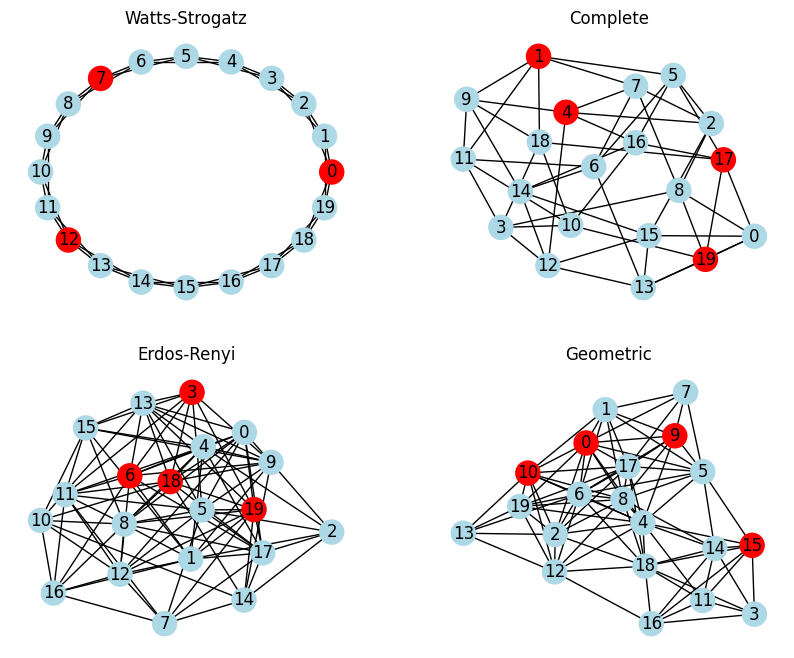

In [12]:
display(fig)